# Exploring with plots: Weather Data

Peter Ralph  
2026-01-13

# Weather Underground

Associated with WU is a large number of [Personal Weather
Stations](https://www.wunderground.com/pws/overview)

<figure>
<a
href="https://www.wunderground.com/wundermap?lat=44.058&amp;lon=-123.105">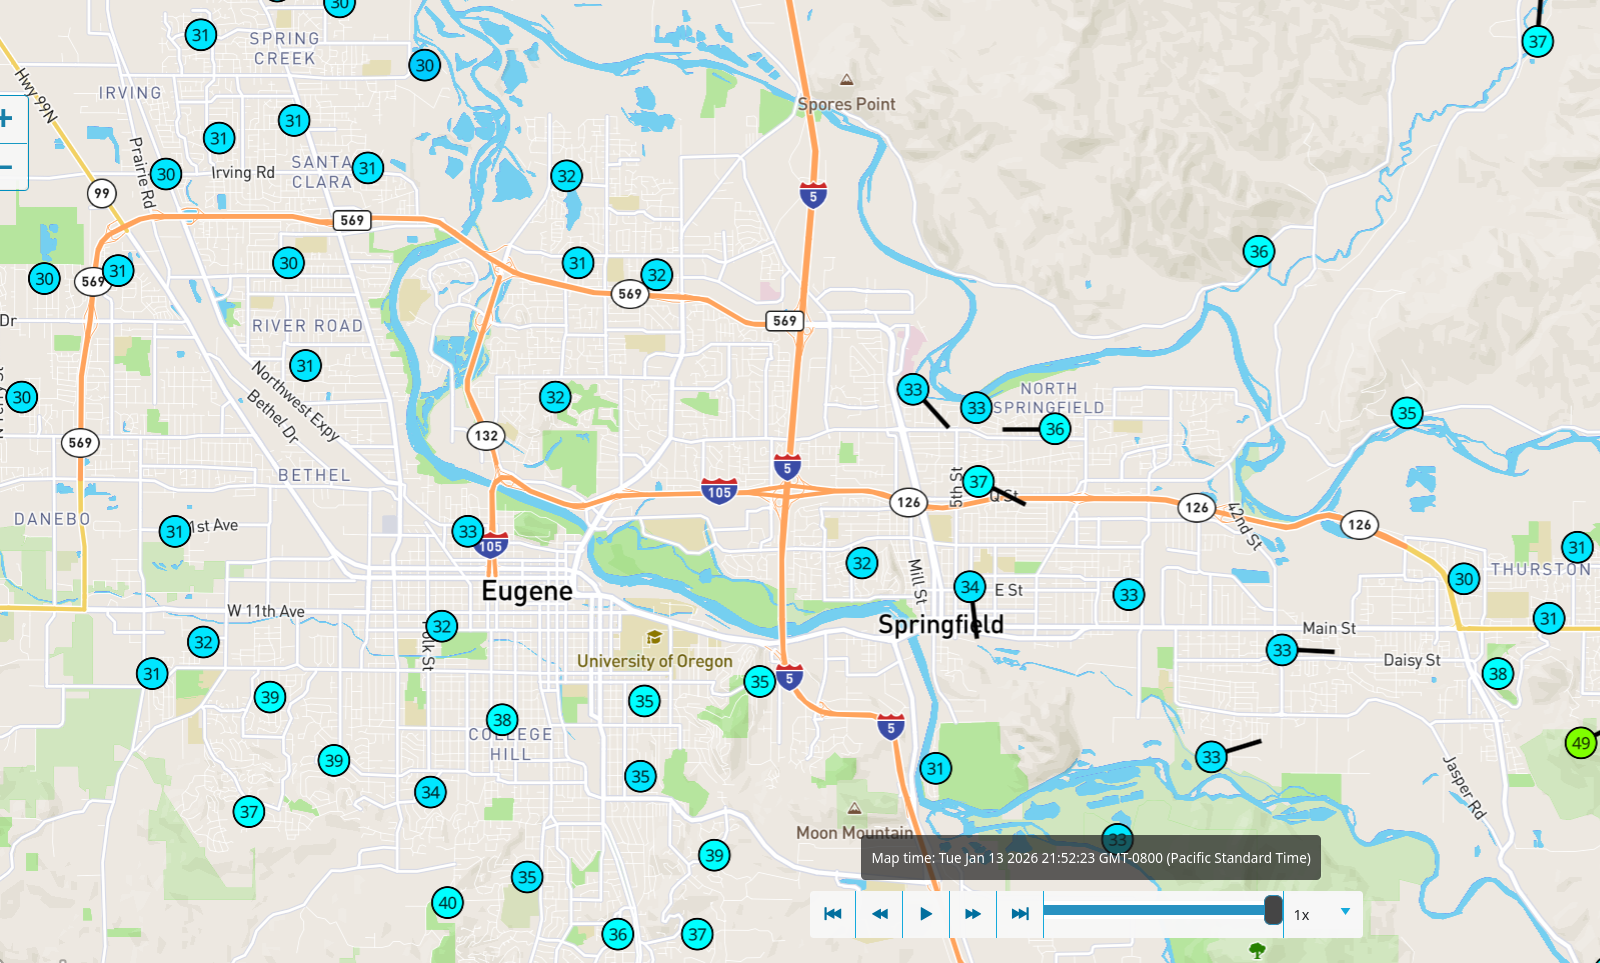</a>
<figcaption>map of weather underground stations in
Eugene/Springfield</figcaption>
</figure>

## 

From these, data is available:

<figure>
<a href="https://www.wunderground.com/dashboard/pws/KOREUGEN127">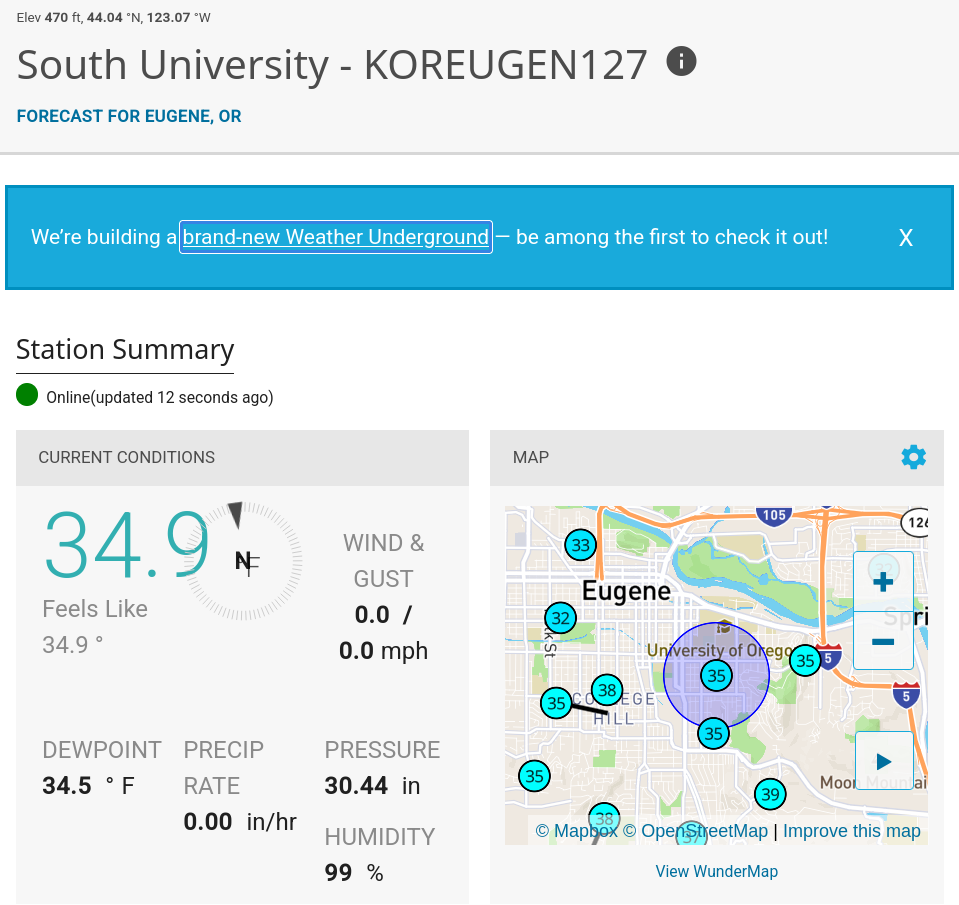</a>
<figcaption>screenshot of KOREUGEN127</figcaption>
</figure>

## 

… every five minutes:

<figure>
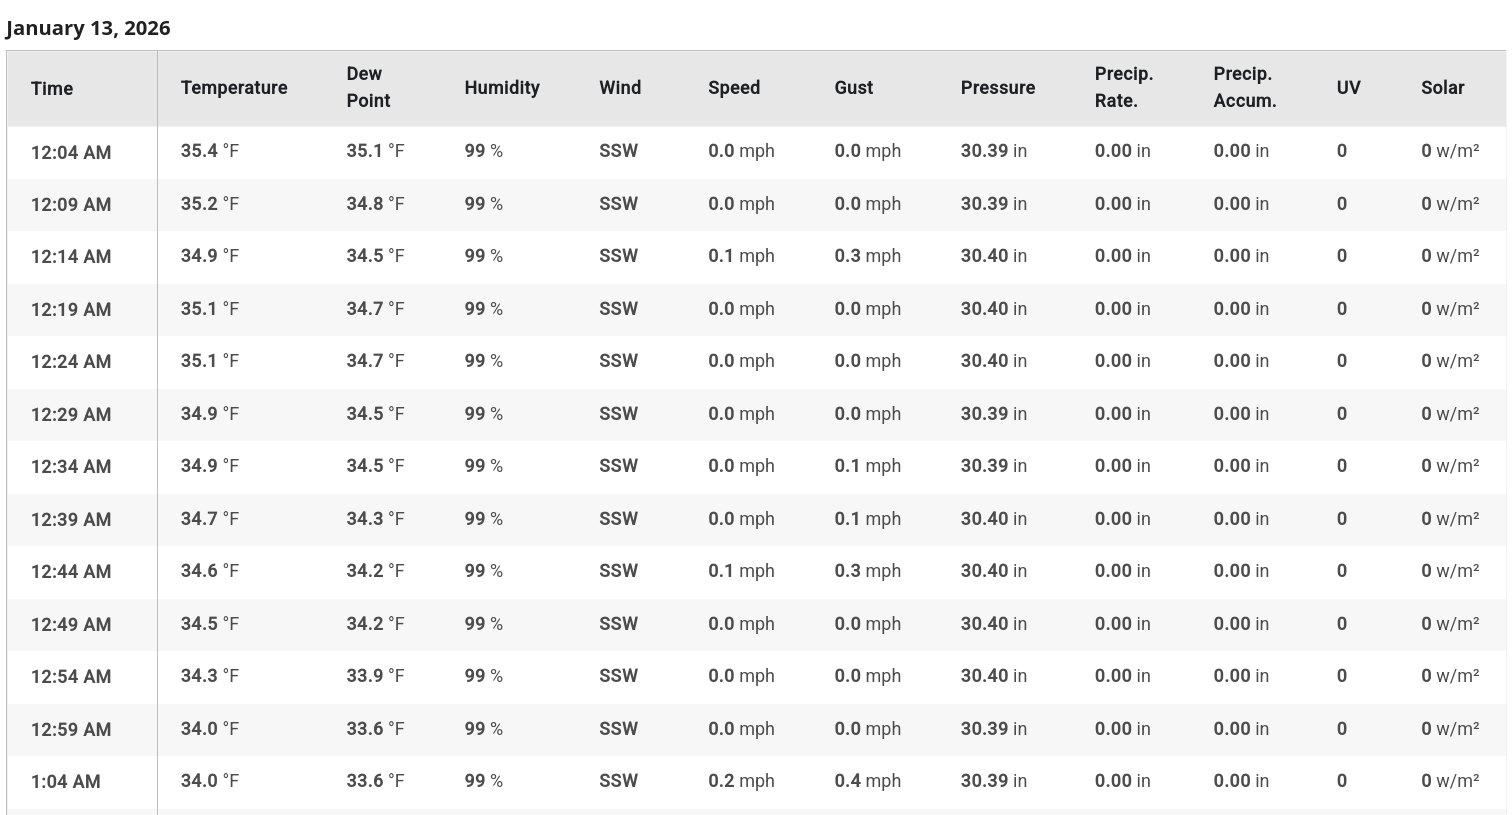
<figcaption aria-hidden="true">screenshot of data from that station in
an HTML table</figcaption>
</figure>

## Web scraping

Happily, someone has written a
[scraper](https://github.com/Karlheinzniebuhr/the-weather-scraper):

    git clone git@github.com:Karlheinzniebuhr/the-weather-scraper.git
    cd the-weather-scraper
    pip install lxml requests
    # edit stations.txt and config.py
    python weather_scraper.py

and then WAIT. (There’s 5-second timeouts between requests.)

I’ve done some for you:

-   a table of local stations: [stations.csv](data/stations.csv)
-   a zip file of data from 2025:
    [weather_2025.zip](data/weather_2025.zip)

Let’s have a look! *(unzip the file to `data/`)*

In [ ]:
import pandas as pd
import plotnine as p9
import glob

stations = pd.read_csv("data/stations.csv")
stations

Better would be with a map for background, but this is okay:

In [ ]:
(
    p9.ggplot(stations, p9.aes(x="lon", y="lat", color="elev")) 
    + p9.geom_point(size=4)
    + p9.theme(aspect_ratio=1.0)
    + p9.geom_text(p9.aes(label='name'), ha='left', nudge_x=0.004)
)

Each station has it’s own file:

In [ ]:
def read_wf(f):
    x = pd.read_csv(f).convert_dtypes()
    x['code'] = f.split("/")[-1].split(".")[0]
    return x

    
wfiles = glob.glob("data/weather_data/*.csv")

weather = pd.concat([read_wf(f) for f in wfiles])
weather

## Goals:

What we’d like to do is **understand how well rainfall in one part of
Eugene/Springfield predicts rainfall in another part**. In particular,
how well does rainfall at one point – the [National Weather Service
station](https://forecast.weather.gov/MapClick.php?lat=44.0520691&lon=-123.08675360000001)
– predict load for the municipal stormwater system?

*So:* let’s understand the data, with this goal in mind.